In [1]:
import pandas as pd
import numpy as np
from statsmodels.nonparametric.kernel_density import KDEMultivariate
from sklearn.preprocessing import LabelEncoder, StandardScaler
import umap


/opt/anaconda3/envs/se/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Preprocessing

In [16]:
ps = pd.read_csv("./data/ParaSuit_t.csv")
ps


,Trials,switch-type,max-memory-inhibit,max-sym-array-size,max-depth,watchdog,max-static-fork-pct,const-array-opt,zero-seed-extension,smtlib-display-constants,...,batch-time,max-static-solve-pct,max-static-cpfork-pct,max-static-cpsolve-pct,array-value-symb-ratio,sym-arg,sym-flies,sym-stdin,Coverage,Accumulated Coverage
0,1,internal,False,3980,1142,True,0.159269,True,False,bin,...,4s,0.392040,0.197067,0.029739,0.896605,"[15, 15]",1 26,4,0,0
1,2,llvm,True,6067,2189,True,0.798309,True,True,bin,...,7s,0.848477,0.372759,0.209427,0.780304,"[4, 16, 16, 18, 16]",1 15,11,1850,1850
2,3,llvm,False,3104,646,True,0.238140,True,False,dec,...,4s,0.922272,0.613608,0.533229,0.582163,"[8, 8]",2 3,4,2562,2643
3,4,internal,False,5791,1579,False,0.641675,False,True,dec,...,6s,0.464663,0.849170,0.521843,0.401757,"[3, 10, 3, 9, 10, 3]",1 11,4,1296,2652
4,5,internal,True,2356,537,True,0.893913,False,True,bin,...,4s,0.538513,0.410924,0.766638,0.351363,"[2, 1, 15, 7, 4, 11, 15]",1 29,8,1281,2666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,347,llvm,True,63,590,False,0.309275,True,False,bin,...,76s,0.957655,0.036121,0.395685,0.454692,"[20, 20, 1]",1 21,10,1624,3908
347,348,llvm,False,519,639,False,0.309275,True,False,dec,...,40s,0.957655,0.968147,0.047696,0.454692,[15],2 19,10,0,3908
348,349,llvm,False,338,544,True,0.309275,True,False,dec,...,76s,0.354454,0.034160,0.915171,0.667569,"[1, 14, 5]",1 29,4,929,3908
349,350,llvm,False,338,710,True,0.309275,True,True,bin,...,76s,0.957655,0.841217,0.469565,0.206281,"[6, 6]",2 7,4,2648,3908


In [17]:
ps = ps.drop("Accumulated Coverage", axis=1)
ps


,Trials,switch-type,max-memory-inhibit,max-sym-array-size,max-depth,watchdog,max-static-fork-pct,const-array-opt,zero-seed-extension,smtlib-display-constants,...,max-memory,batch-time,max-static-solve-pct,max-static-cpfork-pct,max-static-cpsolve-pct,array-value-symb-ratio,sym-arg,sym-flies,sym-stdin,Coverage
0,1,internal,False,3980,1142,True,0.159269,True,False,bin,...,1136,4s,0.392040,0.197067,0.029739,0.896605,"[15, 15]",1 26,4,0
1,2,llvm,True,6067,2189,True,0.798309,True,True,bin,...,2040,7s,0.848477,0.372759,0.209427,0.780304,"[4, 16, 16, 18, 16]",1 15,11,1850
2,3,llvm,False,3104,646,True,0.238140,True,False,dec,...,1098,4s,0.922272,0.613608,0.533229,0.582163,"[8, 8]",2 3,4,2562
3,4,internal,False,5791,1579,False,0.641675,False,True,dec,...,1242,6s,0.464663,0.849170,0.521843,0.401757,"[3, 10, 3, 9, 10, 3]",1 11,4,1296
4,5,internal,True,2356,537,True,0.893913,False,True,bin,...,711,4s,0.538513,0.410924,0.766638,0.351363,"[2, 1, 15, 7, 4, 11, 15]",1 29,8,1281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,347,llvm,True,63,590,False,0.309275,True,False,bin,...,569,76s,0.957655,0.036121,0.395685,0.454692,"[20, 20, 1]",1 21,10,1624
347,348,llvm,False,519,639,False,0.309275,True,False,dec,...,133,40s,0.957655,0.968147,0.047696,0.454692,[15],2 19,10,0
348,349,llvm,False,338,544,True,0.309275,True,False,dec,...,209,76s,0.354454,0.034160,0.915171,0.667569,"[1, 14, 5]",1 29,4,929
349,350,llvm,False,338,710,True,0.309275,True,True,bin,...,133,76s,0.957655,0.841217,0.469565,0.206281,"[6, 6]",2 7,4,2648


In [18]:
time = ['seed-time', 'uncovered-update-interval', 'max-solver-time', 'batch-time']
for t in time:
    ps[t] = ps[t].str.rstrip('s').astype(float)
ps


,Trials,switch-type,max-memory-inhibit,max-sym-array-size,max-depth,watchdog,max-static-fork-pct,const-array-opt,zero-seed-extension,smtlib-display-constants,...,max-memory,batch-time,max-static-solve-pct,max-static-cpfork-pct,max-static-cpsolve-pct,array-value-symb-ratio,sym-arg,sym-flies,sym-stdin,Coverage
0,1,internal,False,3980,1142,True,0.159269,True,False,bin,...,1136,4.0,0.392040,0.197067,0.029739,0.896605,"[15, 15]",1 26,4,0
1,2,llvm,True,6067,2189,True,0.798309,True,True,bin,...,2040,7.0,0.848477,0.372759,0.209427,0.780304,"[4, 16, 16, 18, 16]",1 15,11,1850
2,3,llvm,False,3104,646,True,0.238140,True,False,dec,...,1098,4.0,0.922272,0.613608,0.533229,0.582163,"[8, 8]",2 3,4,2562
3,4,internal,False,5791,1579,False,0.641675,False,True,dec,...,1242,6.0,0.464663,0.849170,0.521843,0.401757,"[3, 10, 3, 9, 10, 3]",1 11,4,1296
4,5,internal,True,2356,537,True,0.893913,False,True,bin,...,711,4.0,0.538513,0.410924,0.766638,0.351363,"[2, 1, 15, 7, 4, 11, 15]",1 29,8,1281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,347,llvm,True,63,590,False,0.309275,True,False,bin,...,569,76.0,0.957655,0.036121,0.395685,0.454692,"[20, 20, 1]",1 21,10,1624
347,348,llvm,False,519,639,False,0.309275,True,False,dec,...,133,40.0,0.957655,0.968147,0.047696,0.454692,[15],2 19,10,0
348,349,llvm,False,338,544,True,0.309275,True,False,dec,...,209,76.0,0.354454,0.034160,0.915171,0.667569,"[1, 14, 5]",1 29,4,929
349,350,llvm,False,338,710,True,0.309275,True,True,bin,...,133,76.0,0.957655,0.841217,0.469565,0.206281,"[6, 6]",2 7,4,2648


In [9]:
ps.describe

<bound method NDFrame.describe of      Trials switch-type  max-memory-inhibit  max-sym-array-size  max-depth  \
0         1    internal               False                3980       1142   
1         2        llvm                True                6067       2189   
2         3        llvm               False                3104        646   
3         4    internal               False                5791       1579   
4         5    internal                True                2356        537   
..      ...         ...                 ...                 ...        ...   
346     347        llvm                True                  63        590   
347     348        llvm               False                 519        639   
348     349        llvm               False                 338        544   
349     350        llvm               False                 338        710   
350     351        llvm                True                  63        637   

     watchdog  max-static-for

In [10]:
# boolean data 전처리
import numpy as np
boolean = np.array([True, False], dtype=np.bool_)
boolean_list = boolean.tolist()
boolean = []
for col in ps.columns:
    if col in ['sym-arg', 'sym-flies']:
        continue
    if ps[col].dtype == "bool":
        print(f"{col}: {ps[col].unique()}")
        data ={
            "name": col,
            "values": boolean_list,
            "displayName": ''.join(part[0].upper() for part in col.split('-')),
            "type": "boolean",
            "valueType": "boolean"
        }
        boolean.append(data)
        print()

print(len(boolean))
boolean

        

max-memory-inhibit: [False  True]

watchdog: [ True False]

const-array-opt: [ True False]

zero-seed-extension: [False  True]

warnings-only-to-file: [False  True]

smtlib-human-readable: [ True False]

warn-all-external-symbols: [ True False]

use-iterative-deepening-time-search: [ True False]

cex-cache-exp: [ True False]

all-external-warnings: [ True False]

readable-posix-inputs: [False  True]

klee-call-optimisation: [False  True]

use-construct-hash-stp: [ True False]

use-visitor-hash: [False  True]

return-null-on-zero-malloc: [False  True]

emit-all-errors: [False  True]

disable-inlining: [False  True]

solver-optimize-divides: [ True False]

equality-substitution: [ True False]

cex-cache-try-all: [False  True]

simplify-sym-indices: [False  True]

check-overshift: [ True False]

check-div-zero: [ True False]

named-seed-matching: [False  True]

disable-verify: [ True False]

use-branch-cache: [False  True]

use-independent-solver: [False  True]

track-instruction-time: [F

[{'name': 'max-memory-inhibit',
  'values': [True, False],
  'displayName': 'MMI',
  'type': 'boolean',
  'valueType': 'boolean'},
 {'name': 'watchdog',
  'values': [True, False],
  'displayName': 'W',
  'type': 'boolean',
  'valueType': 'boolean'},
 {'name': 'const-array-opt',
  'values': [True, False],
  'displayName': 'CAO',
  'type': 'boolean',
  'valueType': 'boolean'},
 {'name': 'zero-seed-extension',
  'values': [True, False],
  'displayName': 'ZSE',
  'type': 'boolean',
  'valueType': 'boolean'},
 {'name': 'warnings-only-to-file',
  'values': [True, False],
  'displayName': 'WOTF',
  'type': 'boolean',
  'valueType': 'boolean'},
 {'name': 'smtlib-human-readable',
  'values': [True, False],
  'displayName': 'SHR',
  'type': 'boolean',
  'valueType': 'boolean'},
 {'name': 'warn-all-external-symbols',
  'values': [True, False],
  'displayName': 'WAES',
  'type': 'boolean',
  'valueType': 'boolean'},
 {'name': 'use-iterative-deepening-time-search',
  'values': [True, False],
  'dis

In [12]:
# Catogorical data 전처리

categorical = []
for col in ps.columns:
    if col in ['sym-arg', 'sym-flies']:
        continue
    if ps[col].dtype == "object":
        print(f"{col}: {ps[col].unique()}")
        data ={
            "name": col,
            "values": list(ps[col].unique()),
            "displayName": ''.join(part[0].upper() for part in col.split('-')),
            "type": "categorical",
            "valueType": "string"
            
        }
        categorical.append(data)
        print()
print(len(categorical))
categorical

        

switch-type: ['internal' 'llvm' 'simple']

smtlib-display-constants: ['bin' 'dec' 'hex']

smtlib-abbreviation-mode: ['named' 'none' 'let']

3


[{'name': 'switch-type',
  'values': ['internal', 'llvm', 'simple'],
  'displayName': 'ST',
  'type': 'categorical',
  'valueType': 'string'},
 {'name': 'smtlib-display-constants',
  'values': ['bin', 'dec', 'hex'],
  'displayName': 'SDC',
  'type': 'categorical',
  'valueType': 'string'},
 {'name': 'smtlib-abbreviation-mode',
  'values': ['named', 'none', 'let'],
  'displayName': 'SAM',
  'type': 'categorical',
  'valueType': 'string'}]

In [13]:
# continuous data 전처리

ordinal = []
for col in ps.columns:
    # if col in ['sym-arg', 'sym-flies']:
    #     continue
    if ps[col].dtype == "int64" or ps[col].dtype == "float64":
        print(f"{col}: {ps[col].nunique()}")
        values = ps[col].unique()
        
        data ={
            "name": col,
            "values": np.array([values.min(), values.max()]).tolist(),
            "displayName": ''.join(part[0].upper() for part in col.split('-')),
            "type": "numerical",
            "valueType": ps[col].dtype.name == "int64" and "int" or "float"
        }
        ordinal.append(data)
        print()
print(len(ordinal))
ordinal
        

Trials: 351

max-sym-array-size: 191

max-depth: 215

max-static-fork-pct: 199

redzone-size: 60

batch-instructions: 228

array-value-ratio: 207

max-forks: 231

max-stack-frames: 226

seed-time: 89

uncovered-update-interval: 94

max-solver-time: 83

max-memory: 208

batch-time: 107

max-static-solve-pct: 203

max-static-cpfork-pct: 225

max-static-cpsolve-pct: 210

array-value-symb-ratio: 202

sym-stdin: 38

Coverage: 283

20


[{'name': 'Trials',
  'values': [1, 351],
  'displayName': 'T',
  'type': 'numerical',
  'valueType': 'int'},
 {'name': 'max-sym-array-size',
  'values': [37, 6067],
  'displayName': 'MSAS',
  'type': 'numerical',
  'valueType': 'int'},
 {'name': 'max-depth',
  'values': [64, 2189],
  'displayName': 'MD',
  'type': 'numerical',
  'valueType': 'int'},
 {'name': 'max-static-fork-pct',
  'values': [0.001630814, 0.996351828],
  'displayName': 'MSFP',
  'type': 'numerical',
  'valueType': 'float'},
 {'name': 'redzone-size',
  'values': [3, 127],
  'displayName': 'RS',
  'type': 'numerical',
  'valueType': 'int'},
 {'name': 'batch-instructions',
  'values': [370, 13155],
  'displayName': 'BI',
  'type': 'numerical',
  'valueType': 'int'},
 {'name': 'array-value-ratio',
  'values': [0.005026351, 0.993154524],
  'displayName': 'AVR',
  'type': 'numerical',
  'valueType': 'float'},
 {'name': 'max-forks',
  'values': [7, 23699],
  'displayName': 'MF',
  'type': 'numerical',
  'valueType': 'int'}

In [14]:
# list_type data 전처리

list_type = []
for col in ps.columns:
    if col not in ['sym-arg', 'sym-flies']:
        continue
    if ps[col].dtype == "object":
        # print(f"{col}: {ps[col].unique()}")
        if col == 'sym-arg':
            unique_set = set()
            for v in ps[col].unique():
                v = eval(v)
                unique_set.update(v)
            print(unique_set)
        if col == 'sym-flies':
            unique_set = set()
            for v in ps[col].unique():
                v = v.split(" ")
                v = [int(x) for x in v if x]
                unique_set.update(v)
            print(unique_set)
        data ={
            "name": col,
            "values": [min(unique_set), max(unique_set)],
            "displayName": ''.join(part[0].upper() for part in col.split('-')),
            "type": "list",
            "valueType": "list"
            
        }
        list_type.append(data)
        print()
print(len(list_type))
list_type

        

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20}

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30}

2


[{'name': 'sym-arg',
  'values': [1, 20],
  'displayName': 'SA',
  'type': 'list',
  'valueType': 'list'},
 {'name': 'sym-flies',
  'values': [1, 30],
  'displayName': 'SF',
  'type': 'list',
  'valueType': 'list'}]

In [15]:
import json
data = {"hyperparameters": boolean+ categorical+ ordinal +list_type}

with open("column.json", "w") as f:
    json.dump(data, f, indent=4)
    

In [21]:
import json
all_data = []
for row in ps.iterrows():
    config = {row[1].index[i]: row[1][i] for i in range(len(row[1]))}
    # for other in ["sym-arg", "sym-fli
    config["sym-arg"] = eval(config["sym-arg"])
    config["sym-flies"] = [int(x) for x in config["sym-flies"].split(" ") if x]

    coverage = config.pop("Coverage")
    trial_id = config.pop("Trials")
    data = {
        "id": trial_id,
        "config": config,
        "metric": coverage
    }
    all_data.append(data)

with open("ParaSuit.json", "w") as f:
    json.dump(all_data, f, indent=4)


/var/folders/ky/_fj_kndj5f782s7g4py53w680000gn/T/ipykernel_27197/4190316819.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  config = {row[1].index[i]: row[1][i] for i in range(len(row[1]))}


In [5]:
def load_csv(path):
    df = pd.read_csv(path).T
    df.columns = df.iloc[0]
    df = df.drop(df.index[0])
    # df = df.drop('Accumulated Coverage', axis=1)
    return df

ps = load_csv("ParaSuit.csv")

ps.to_csv("ParaSuit_t.csv")
ps

Parameters / Trials,switch-type,max-memory-inhibit,max-sym-array-size,max-depth,watchdog,max-static-fork-pct,const-array-opt,zero-seed-extension,smtlib-display-constants,warnings-only-to-file,...,batch-time,max-static-solve-pct,max-static-cpfork-pct,max-static-cpsolve-pct,array-value-symb-ratio,sym-arg,sym-flies,sym-stdin,Coverage,Accumulated Coverage
1,internal,FALSE,3980,1142,TRUE,0.159269079,TRUE,FALSE,bin,FALSE,...,4s,0.392040116,0.19706679,0.029738674,0.896604851,"[15, 15]",1 26,4,0,0
2,llvm,TRUE,6067,2189,TRUE,0.79830871,TRUE,TRUE,bin,FALSE,...,7s,0.848476943,0.37275923,0.209427397,0.780304309,"[4, 16, 16, 18, 16]",1 15,11,1850,1850
3,llvm,FALSE,3104,646,TRUE,0.238140474,TRUE,FALSE,dec,TRUE,...,4s,0.922272202,0.613607527,0.53322881,0.582162663,"[8, 8]",2 3,4,2562,2643
4,internal,FALSE,5791,1579,FALSE,0.641675264,FALSE,TRUE,dec,FALSE,...,6s,0.464663364,0.849170368,0.52184323,0.401756573,"[3, 10, 3, 9, 10, 3]",1 11,4,1296,2652
5,internal,TRUE,2356,537,TRUE,0.893913349,FALSE,TRUE,bin,TRUE,...,4s,0.538512739,0.410923641,0.766638041,0.351362796,"[2, 1, 15, 7, 4, 11, 15]",1 29,8,1281,2666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,llvm,TRUE,63,590,FALSE,0.30927503,TRUE,FALSE,bin,TRUE,...,76s,0.957655445,0.036120738,0.395684701,0.454691958,"[20, 20, 1]",1 21,10,1624,3908
348,llvm,FALSE,519,639,FALSE,0.30927503,TRUE,FALSE,dec,FALSE,...,40s,0.957655445,0.96814717,0.047695641,0.454691958,[15],2 19,10,0,3908
349,llvm,FALSE,338,544,TRUE,0.30927503,TRUE,FALSE,dec,TRUE,...,76s,0.354453773,0.034159663,0.915170636,0.667569495,"[1, 14, 5]",1 29,4,929,3908
350,llvm,FALSE,338,710,TRUE,0.30927503,TRUE,TRUE,bin,FALSE,...,76s,0.957655445,0.841217412,0.469564775,0.206281263,"[6, 6]",2 7,4,2648,3908


In [137]:
def calculate_density(df):
    numeric = list(df.columns)

    categorical = ['switch-type', 'max-memory-inhibit', 'watchdog', 'const-array-opt', 'zero-seed-extension', 'smtlib-display-constants', 'warnings-only-to-file', 'smtlib-human-readable','warn-all-external-symbols','use-iterative-deepening-time-search','cex-cache-exp','all-external-warnings','readable-posix-inputs','klee-call-optimisation','smtlib-abbreviation-mode','use-construct-hash-stp','use-visitor-hash','return-null-on-zero-malloc','emit-all-errors',
    'disable-inlining','solver-optimize-divides','equality-substitution','cex-cache-try-all','simplify-sym-indices','check-overshift','check-div-zero','named-seed-matching','disable-verify','use-branch-cache','use-independent-solver','track-instruction-time','use-call-paths','silent-klee-assume','use-cex-cache','suppress-external-warnings','use-forked-solver', 'cex-cache-superset','verify-each']

    time = ['seed-time', 'uncovered-update-interval', 'max-solver-time', 'batch-time']

    other = ['sym-arg', 'sym-flies']

    for c in categorical:   
        numeric.remove(c)
    for t in time:
        numeric.remove(t)
    for o in other:
        numeric.remove(o)
    # other 인코딩
    df['sym-arg'] = df['sym-arg'].apply(lambda x: np.mean(eval(x)))
    df['sym-flies'] = df['sym-flies'].apply(lambda x: np.mean([int(num) for num in x.split()]))
    # 범주형 인코딩
    le = LabelEncoder()
    for col in categorical:
        df[col] = le.fit_transform(df[col])
    for t in time:
        df[t] = df[t].str.rstrip('s').astype(float)

    # continuous 인코딩
    scaler = StandardScaler()
    for c in time+numeric+other:
        df[c] = scaler.fit_transform(df[[c]])
    var_type = 'u' * len(categorical) + 'c' * len(time+numeric+other)
    bandwidth = [0.5] * len(categorical+time+numeric+other)  # 대역폭 설정, 실제 데이터에 맞게 조절 필요
    
    # KDEMultivariate 모델 생성 및 적합
    kde = KDEMultivariate(data=df[categorical + time + numeric + other], var_type=var_type, bw=bandwidth)
    
    # 밀도 추정
    density_estimates = kde.pdf(df[categorical + time + numeric + other].values)

    return np.array(density_estimates)


In [148]:
def to_embedding(density_estimates):
    reducer = umap.UMAP(random_state=42)
    # 밀도 추정치의 차원을 (n_samples, n_features) 형태로 조정
    # UMAP은 기본적으로 2차원 배열을 입력으로 기대하기 때문에, 밀도 추정치를 열 벡터로 변환합니다.
    density_estimates_reshaped = density_estimates.reshape(-1, 1)

    # 밀도 추정치를 사용하여 UMAP 학습
    embedding = reducer.fit_transform(density_estimates_reshaped)
    return embedding

def plot_umap(embedding, df):
    import matplotlib.pyplot as plt

    plt.scatter(embedding[:, 0], embedding[:, 1], c=df['Coverage'], cmap='Spectral', s=5)
    plt.colorbar(label='Coverage')
    plt.title('UMAP projection of the density estimates')
    plt.show()

/opt/anaconda3/envs/se/lib/python3.11/site-packages/statsmodels/nonparametric/kernels.py:62: RuntimeWarning: divide by zero encountered in divide
  kernel_value = np.ones(Xi.size) * h / (num_levels - 1)
/opt/anaconda3/envs/se/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


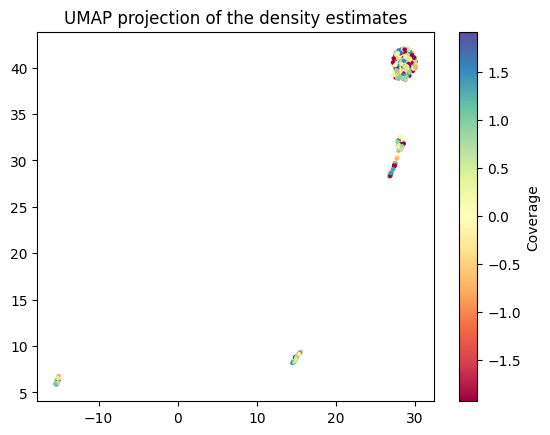

In [149]:
ps_df = load_csv('./ParaSuit.csv')
ps_density = calculate_density(ps_df)
ps_embed = to_embedding(ps_density)
plot_umap(ps_embed, ps_df)

In [153]:
ps_df['Coverage']

1     -1.930011
2      0.404067
3      1.302371
4     -0.294895
5     -0.313820
         ...   
347    0.118931
348   -1.930011
349   -0.757926
350    1.410874
351    0.260237
Name: Coverage, Length: 351, dtype: float64

/opt/anaconda3/envs/se/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


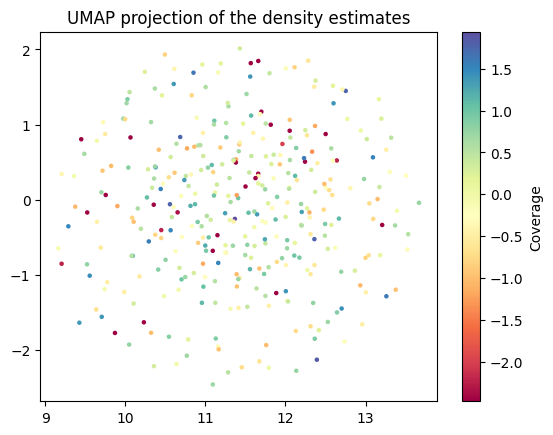

In [150]:
sh_df = load_csv('./SucHalving.csv')
sh_density = calculate_density(sh_df)
sh_embed = to_embedding(sh_density)
plot_umap(sh_embed, sh_df)

/opt/anaconda3/envs/se/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


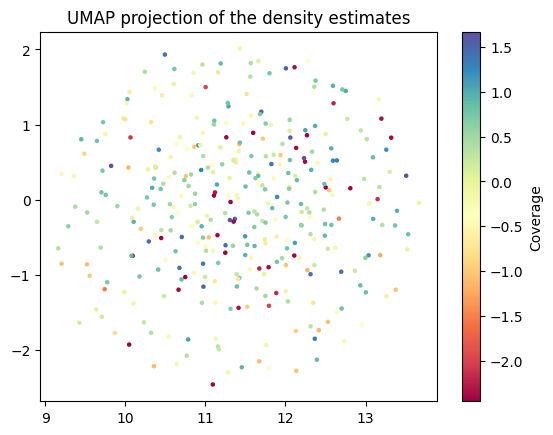

In [151]:
tpe_df = load_csv('./TPE.csv')
tpe_density = calculate_density(tpe_df)
tpe_embed = to_embedding(tpe_density)
plot_umap(tpe_embed, tpe_df)

In [111]:
numeric = list(ps_df.columns)

categorical = ['switch-type', 'max-memory-inhibit', 'watchdog', 'const-array-opt', 'zero-seed-extension', 'smtlib-display-constants', 'warnings-only-to-file', 'smtlib-human-readable','warn-all-external-symbols','use-iterative-deepening-time-search','cex-cache-exp','all-external-warnings','readable-posix-inputs','klee-call-optimisation','smtlib-abbreviation-mode','use-construct-hash-stp','use-visitor-hash','return-null-on-zero-malloc','emit-all-errors',
'disable-inlining','solver-optimize-divides','equality-substitution','cex-cache-try-all','simplify-sym-indices','check-overshift','check-div-zero','named-seed-matching','disable-verify','use-branch-cache','use-independent-solver','track-instruction-time','use-call-paths','silent-klee-assume','use-cex-cache','suppress-external-warnings','use-forked-solver', 'cex-cache-superset','verify-each']

time = ['seed-time', 'uncovered-update-interval', 'max-solver-time', 'batch-time']

other = ['sym-arg', 'sym-flies']

for c in categorical:   
    numeric.remove(c)
for t in time:
    numeric.remove(t)
for o in other:
    numeric.remove(o)


['max-sym-array-size',
 'max-depth',
 'max-static-fork-pct',
 'redzone-size',
 'batch-instructions',
 'array-value-ratio',
 'max-forks',
 'max-stack-frames',
 'max-memory',
 'max-static-solve-pct',
 'max-static-cpfork-pct',
 'max-static-cpsolve-pct',
 'array-value-symb-ratio',
 'sym-stdin',
 'Coverage']

In [112]:
# other 인코딩
ps_df['sym-arg'] = ps_df['sym-arg'].apply(lambda x: np.mean(eval(x)))

ps_df['sym-arg']

1      15.000000
2      14.000000
3       8.000000
4       6.333333
5       7.857143
         ...    
347    13.666667
348    15.000000
349     6.666667
350     6.000000
351     9.000000
Name: sym-arg, Length: 351, dtype: float64

In [113]:
ps_df['sym-flies'] = ps_df['sym-flies'].apply(lambda x: np.mean([int(num) for num in x.split()]))


ps_df['sym-flies']

1      13.5
2       8.0
3       2.5
4       6.0
5      15.0
       ... 
347    11.0
348    10.5
349    15.0
350     4.5
351     7.5
Name: sym-flies, Length: 351, dtype: float64

In [114]:
# 범주형 인코딩
le = LabelEncoder()

for col in categorical:
    ps_df[col] = le.fit_transform(ps_df[col])

In [116]:
# time -> s탈락시키기
for t in time:
    ps_df[t] = ps_df[t].str.rstrip('s').astype(float)


In [117]:
# continuous 인코딩
scaler = StandardScaler()
for c in time+numeric+other:
    ps_df[c] = scaler.fit_transform(ps_df[[c]])
    print(c)


seed-time
uncovered-update-interval
max-solver-time
batch-time
max-sym-array-size
max-depth
max-static-fork-pct
redzone-size
batch-instructions
array-value-ratio
max-forks
max-stack-frames
max-memory
max-static-solve-pct
max-static-cpfork-pct
max-static-cpsolve-pct
array-value-symb-ratio
sym-stdin
Coverage
sym-arg
sym-flies


In [118]:
# 리스트 데이터 처리 예시 (sym-arg의 평균값을 계산하여 사용)
# ps_df['sym-arg'] = ps_df['sym-arg'].apply(lambda x: eval(x))
# ps_df['sym-arg-mean'] = ps_df['sym-arg'].apply(lambda x: sum(x) / len(x))

# 선택된 변수에 대해 KDEMultivariate 적용
# 데이터 타입 설정 ('u': 범주형, 'c': 연속형)
var_type = 'u' * len(categorical) + 'c' * len(time+numeric+other)
var_type

'uuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuccccccccccccccccccccc'

In [119]:
bandwidth = [0.5] * len(categorical+time+numeric+other)  # 대역폭 설정, 실제 데이터에 맞게 조절 필요

# KDEMultivariate 모델 생성 및 적합
kde = KDEMultivariate(data=ps_df[categorical + time + numeric + other], var_type=var_type, bw=bandwidth)

# 밀도 추정
density_estimates = kde.pdf(ps_df[categorical + time + numeric + other].values)

print(density_estimates)

/opt/anaconda3/envs/se/lib/python3.11/site-packages/statsmodels/nonparametric/kernels.py:62: RuntimeWarning: divide by zero encountered in divide
  kernel_value = np.ones(Xi.size) * h / (num_levels - 1)


[9.04262122e-17 9.04262122e-17 9.04262122e-17 9.04262122e-17
 9.04262122e-17 9.04262122e-17 9.04262122e-17 9.04262122e-17
 9.04262125e-17 9.04262122e-17 9.04262123e-17 9.04262122e-17
 9.04262123e-17 9.04262122e-17 9.04262122e-17 9.04262122e-17
 9.04262122e-17 9.04262122e-17 9.04262122e-17 9.04262503e-17
 9.04262122e-17 9.04262201e-17 9.04263891e-17 9.04262729e-17
 9.04262122e-17 9.04395306e-17 9.04262124e-17 9.04262123e-17
 9.04278888e-17 9.04263931e-17 9.04262475e-17 9.04268524e-17
 9.04262474e-17 9.04262123e-17 9.04262963e-17 9.04266085e-17
 9.04268430e-17 9.04263160e-17 9.04379319e-17 9.04268154e-17
 9.04262301e-17 9.04262122e-17 9.04262123e-17 9.04262123e-17
 9.04262124e-17 9.04263009e-17 9.04262160e-17 9.04262159e-17
 9.04262124e-17 9.04262123e-17 9.04262124e-17 9.04262884e-17
 9.04262122e-17 9.04262591e-17 9.04262122e-17 9.04262129e-17
 9.04262124e-17 9.04262123e-17 9.04262122e-17 9.04262885e-17
 9.04262470e-17 9.04264464e-17 9.04262122e-17 9.04262122e-17
 9.04262123e-17 9.042623

In [120]:
density_estimates = np.array(density_estimates)
density_estimates

reducer = umap.UMAP(random_state=42)

# 밀도 추정치의 차원을 (n_samples, n_features) 형태로 조정
# UMAP은 기본적으로 2차원 배열을 입력으로 기대하기 때문에, 밀도 추정치를 열 벡터로 변환합니다.
density_estimates_reshaped = density_estimates.reshape(-1, 1)

# 밀도 추정치를 사용하여 UMAP 학습
embedding = reducer.fit_transform(density_estimates_reshaped)

# 결과 출력
print(embedding)

/opt/anaconda3/envs/se/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


[[ 27.994734   39.992413 ]
 [ 29.177448   40.76057  ]
 [ 28.956797   40.61513  ]
 [ 27.930988   40.47995  ]
 [ 28.796368   40.832275 ]
 [ 29.442549   40.58315  ]
 [ 29.11941    40.571583 ]
 [ 29.171211   40.094776 ]
 [ 28.542044   40.58273  ]
 [ 28.30827    39.791615 ]
 [ 27.921421   40.73119  ]
 [ 27.725967   40.782127 ]
 [ 28.072546   40.81377  ]
 [ 29.33316    40.489033 ]
 [ 29.042736   40.675373 ]
 [ 28.353907   40.067345 ]
 [ 28.98795    40.56381  ]
 [ 27.891806   40.58463  ]
 [ 28.29474    40.61346  ]
 [ 28.051903   31.918745 ]
 [ 28.972612   39.720947 ]
 [ 28.736881   40.468143 ]
 [ 27.016802   28.60613  ]
 [ 28.192715   31.236246 ]
 [ 28.879496   40.57999  ]
 [-15.170885    6.154135 ]
 [ 28.220213   40.175964 ]
 [ 28.695593   39.91777  ]
 [ 14.5915165   8.42434  ]
 [ 26.873215   28.500607 ]
 [ 28.11511    31.911543 ]
 [ 15.0953865   8.890008 ]
 [ 28.292028   31.862516 ]
 [ 29.288843   40.04222  ]
 [ 27.775284   30.362078 ]
 [ 15.507801    9.330664 ]
 [ 15.1717825   8.896314 ]
 

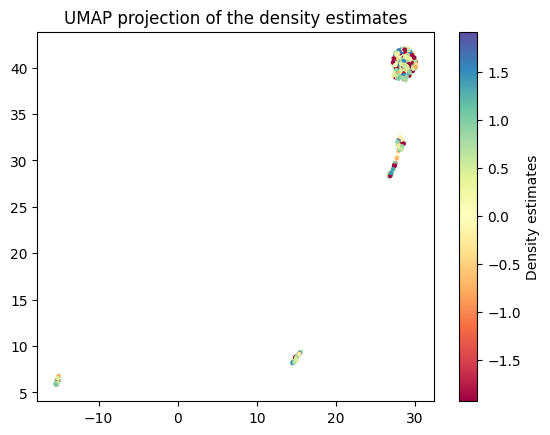

In [123]:
import matplotlib.pyplot as plt

plt.scatter(embedding[:, 0], embedding[:, 1], c=ps_df['Coverage'], cmap='Spectral', s=5)
plt.colorbar(label='Density estimates')
plt.title('UMAP projection of the density estimates')
plt.show()